<a href="https://colab.research.google.com/github/adharsh-codes/aiml-assignment/blob/main/carprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

Using Colab cache for faster access to the 'vehicle-dataset-from-cardekho' dataset.


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

## Load Data

First, I will load the dataset into a pandas DataFrame and display its basic information to understand its structure.

In [3]:
# Load the dataset
df = pd.read_csv(f'{path}/CAR DETAILS FROM CAR DEKHO.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display basic information about the DataFrame
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


## Data Preprocessing

Before training the models, I need to preprocess the data. This involves:
1.  **Handling categorical features**: Converting categorical columns into numerical format using one-hot encoding.
2.  **Defining features (X) and target (y)**: 'Selling_Price' will be our target variable.
3.  **Splitting data**: Dividing the dataset into training and testing sets.

In [8]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop('selling_price', axis=1)
y = df_encoded['selling_price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (3472, 1503)
Shape of X_test: (868, 1503)
Shape of y_train: (3472,)
Shape of y_test: (868,)


## Model Training and Evaluation

Now, I will train and evaluate the requested regression models: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

In [9]:
# 1. Linear Regression
print("\n--- Training Linear Regression ---")
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f"Linear Regression - MSE: {mse_lin:.2f}")
print(f"Linear Regression - RMSE: {rmse_lin:.2f}")
print(f"Linear Regression - R2 Score: {r2_lin:.2f}")


--- Training Linear Regression ---
Linear Regression - MSE: 121717437737.29
Linear Regression - RMSE: 348880.26
Linear Regression - R2 Score: 0.60


In [10]:
# 2. Decision Tree Regressor
print("\n--- Training Decision Tree Regressor ---")
dec_tree_reg = DecisionTreeRegressor(random_state=42)
dec_tree_reg.fit(X_train, y_train)
y_pred_tree = dec_tree_reg.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Decision Tree Regressor - MSE: {mse_tree:.2f}")
print(f"Decision Tree Regressor - RMSE: {rmse_tree:.2f}")
print(f"Decision Tree Regressor - R2 Score: {r2_tree:.2f}")


--- Training Decision Tree Regressor ---
Decision Tree Regressor - MSE: 155460888661.14
Decision Tree Regressor - RMSE: 394285.29
Decision Tree Regressor - R2 Score: 0.49


In [11]:
# 3. Random Forest Regressor
print("\n--- Training Random Forest Regressor ---")
rand_forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rand_forest_reg.fit(X_train, y_train)
y_pred_forest = rand_forest_reg.predict(X_test)

mse_forest = mean_squared_error(y_test, y_pred_forest)
rmse_forest = np.sqrt(mse_forest)
r2_forest = r2_score(y_test, y_pred_forest)

print(f"Random Forest Regressor - MSE: {mse_forest:.2f}")
print(f"Random Forest Regressor - RMSE: {rmse_forest:.2f}")
print(f"Random Forest Regressor - R2 Score: {r2_forest:.2f}")


--- Training Random Forest Regressor ---
Random Forest Regressor - MSE: 129677088255.25
Random Forest Regressor - RMSE: 360107.05
Random Forest Regressor - R2 Score: 0.58


## Note on Logistic Regression

Logistic Regression is a classification algorithm used when the target variable is categorical (e.g., binary: yes/no, true/false, or multi-class: cat/dog/bird). In this dataset, 'Selling_Price' is a continuous numerical variable, making it a regression problem.

Therefore, Logistic Regression is generally not suitable for predicting 'Selling_Price' directly. If you intended to perform a classification task (e.g., classifying cars into price ranges), the 'Selling_Price' would first need to be converted into discrete categories.

## Model Performance Comparison

Let's visualize the performance of the trained models using R2 Score and RMSE to easily compare their effectiveness.

Model Performance Summary:


,Model,R2 Score,RMSE
0,Linear Regression,0.601149,348880.262751
2,Random Forest,0.575066,360107.051105
1,Decision Tree,0.490577,394285.288416


/tmp/ipykernel_21319/3635762986.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=model_performance, palette='viridis')


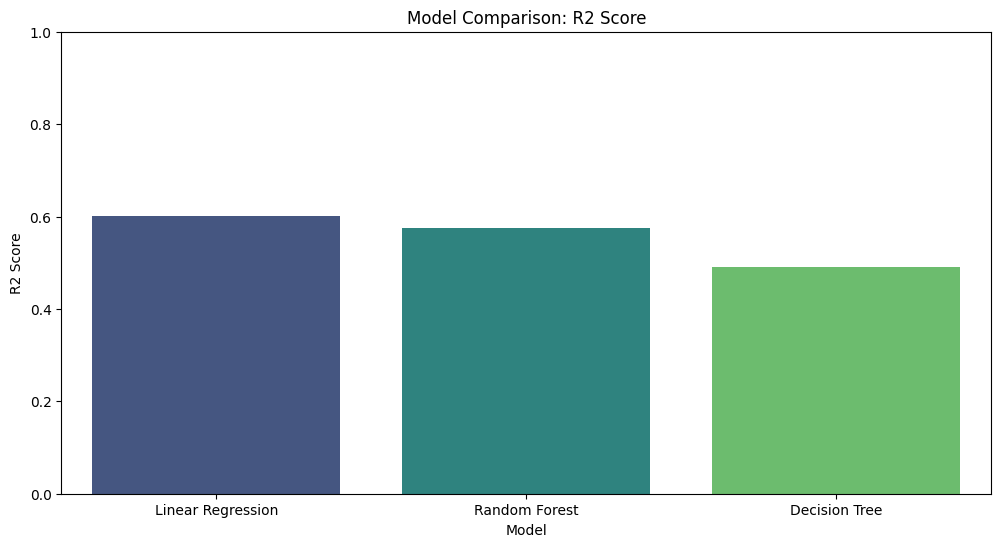

/tmp/ipykernel_21319/3635762986.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=model_performance, palette='plasma')


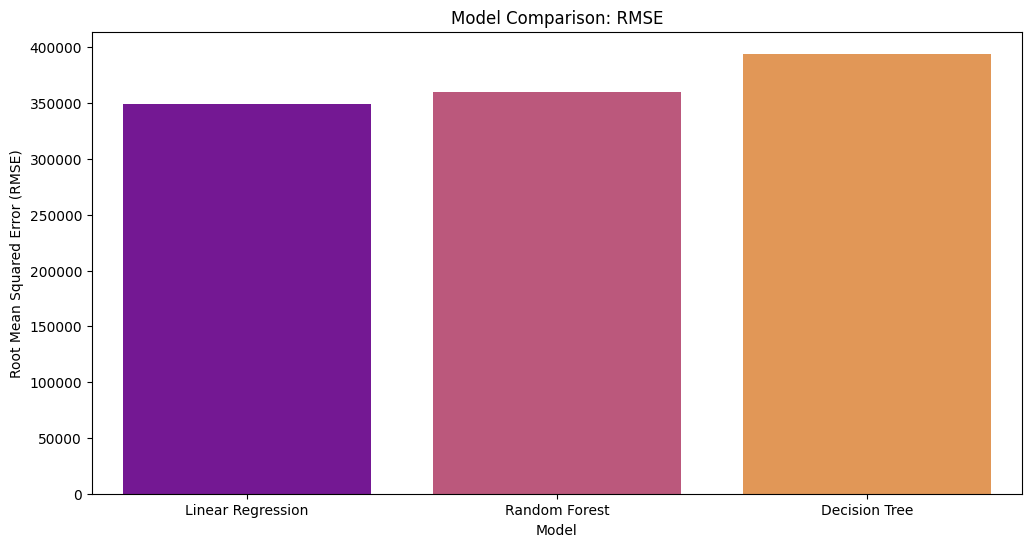

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for model comparison
model_performance = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [r2_lin, r2_tree, r2_forest],
    'RMSE': [rmse_lin, rmse_tree, rmse_forest]
})

# Sort by R2 Score for better visualization
model_performance = model_performance.sort_values(by='R2 Score', ascending=False)

print("Model Performance Summary:")
display(model_performance)

# Create a bar plot for R2 Score
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R2 Score', data=model_performance, palette='viridis')
plt.title('Model Comparison: R2 Score')
plt.ylabel('R2 Score')
plt.ylim(0, 1) # R2 Score typically ranges from 0 to 1 (or less for very bad models)
plt.show()

# Create a bar plot for RMSE
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='RMSE', data=model_performance, palette='plasma')
plt.title('Model Comparison: RMSE')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.show()